In [21]:
import mne
import warnings

mne.set_log_level('ERROR')   # silence MNE
warnings.filterwarnings("ignore")  # silence warnings


In [22]:
import os
import mne
import re
import numpy as np

def load_subject_epochs_4class(subject_id, folder):
    """
    Loads epochs for one subject with 4-class labels:
    1=ISLO, 2=ISLT, 3=ISRO, 4=ISRT
    """

    pattern = re.compile(rf"MI_{subject_id}_S1_B\d+.*\.set")

    files = [f for f in os.listdir(folder) if pattern.match(f)]
    files = sorted(files)

    if len(files) == 0:
        print(f"No files found for subject {subject_id}")
        return None

    print(f"\n--- Loading {subject_id} ---")
    raws = []

    # -----------------------------
    # 1. Load all blocks
    # -----------------------------
    for fname in files:
        print("Loading:", fname)
        raw = mne.io.read_raw_eeglab(os.path.join(folder, fname),
                                     preload=True)
        raws.append(raw)

    raw = mne.concatenate_raws(raws)

    # -----------------------------
    # 2. Drop noisy channels
    # -----------------------------
    bad_chs = {'E48','E119','E49','E113','E94','E23','E24','126','127'}
    bad_present = [ch for ch in raw.ch_names if ch in bad_chs]
    raw.drop_channels(bad_present)
    print("Dropped channels:", bad_present)

    # -----------------------------
    # 3. Filter + Notch
    # -----------------------------
    raw.filter(1., 40., fir_design='firwin')
    raw.notch_filter(50.)

    # -----------------------------
    # 4. Common average reference
    # -----------------------------
    #raw.set_eeg_reference('average')

    # -----------------------------
    # 5. Extract events
    # -----------------------------
    events, event_id = mne.events_from_annotations(raw)
    print("\nOriginal event_id:", event_id)

    # -----------------------------
    # 6. Build 4-class mapping
    # -----------------------------
    class_map = {}

    if 'ISLO' in event_id:
        class_map['ISLO'] = 1
    if 'ISLT' in event_id:
        class_map['ISLT'] = 2
    if 'ISRO' in event_id:
        class_map['ISRO'] = 3
    if 'ISRT' in event_id:
        class_map['ISRT'] = 4

    print("4-class mapping:", class_map)

    # -----------------------------
    # 7. Create epochs
    # -----------------------------
    epochs = mne.Epochs(
        raw, events, event_id=class_map,
        tmin=0.5, tmax=4.5,
        baseline=None,
        preload=True
    )

    print("Epochs shape:", epochs.get_data().shape)
    print("Class counts:", np.unique(epochs.events[:,2], return_counts=True))

    return epochs


In [23]:
folder = r"D:\Shivam MS\MI_final\MI_FINAL_7\Preprocessed_files\Average_ref_set_files"

subject_ids = [f"S{i}" for i in range(1, 20)]

subject_epochs = {}

for sid in subject_ids:
    ep = load_subject_epochs_4class(sid, folder)
    if ep is not None:
        subject_epochs[sid] = ep



--- Loading S1 ---
Loading: MI_S1_S1_B1__20251113_113640_cleaned_avgRef.set
Loading: MI_S1_S1_B2__20251113_111853_cleaned_avgRef.set
Loading: MI_S1_S1_B3_20251113_112429_cleaned_avgRef.set
Loading: MI_S1_S1_B4__20251113_113034_cleaned_avgRef.set
Dropped channels: []

Original event_id: {np.str_('BLCE'): 1, np.str_('BLCS'): 2, np.str_('BLOE'): 3, np.str_('BLOS'): 4, np.str_('EELO'): 5, np.str_('EELT'): 6, np.str_('EERO'): 7, np.str_('EERT'): 8, np.str_('ESLO'): 9, np.str_('ESLT'): 10, np.str_('ESRO'): 11, np.str_('ESRT'): 12, np.str_('IELO'): 13, np.str_('IELT'): 14, np.str_('IERO'): 15, np.str_('IERT'): 16, np.str_('ISLO'): 17, np.str_('ISLT'): 18, np.str_('ISRO'): 19, np.str_('ISRT'): 20, np.str_('OELO'): 21, np.str_('OELT'): 22, np.str_('OERO'): 23, np.str_('OERT'): 24, np.str_('OSLO'): 25, np.str_('OSLT'): 26, np.str_('OSRO'): 27, np.str_('OSRT'): 28, np.str_('RE_1'): 29, np.str_('RE_2'): 30, np.str_('break cnt'): 31}
4-class mapping: {'ISLO': 1, 'ISLT': 2, 'ISRO': 3, 'ISRT': 4}
Ep

In [24]:
import numpy as np
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

def epochs_to_Xy_windowed(epochs, fmin, fmax, win_len=1.0, step=1.0):
    """
    Convert epochs → windowed trials for Riemannian methods
    Returns:
        Xw : (n_windows, n_ch, n_samples)
        yw : (n_windows,)
        trial_id : (n_windows,)
    """
    ep = epochs.copy().filter(fmin, fmax, verbose=False)

    X = ep.get_data()        # (n_trials, n_ch, n_times)
    y = ep.events[:, 2]      # labels
    sfreq = ep.info['sfreq']

    win_samp  = int(win_len * sfreq)
    step_samp = int(step * sfreq)

    Xw, yw, tid = [], [], []

    for ti in range(X.shape[0]):           # loop over trials
        for start in range(0, X.shape[2] - win_samp + 1, step_samp):
            stop = start + win_samp
            Xw.append(X[ti, :, start:stop])
            yw.append(y[ti])
            tid.append(ti)                 # trial index

    return np.array(Xw), np.array(yw), np.array(tid)


LOSO_with_test_window_overlap

In [25]:
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

def cross_subject_riemann_tangent_windowed(
    subject_epochs,
    fmin=8, fmax=30,
    win_len=1,
    step=1,
    clf_type="logreg"
):
    subjects = sorted(subject_epochs.keys())
    print("Subjects:", subjects)

    per_subj_acc = {}
    per_subj_cm  = {}
    all_true, all_pred = [], []

    for test_subj in subjects:
        print("\n================================")
        print(f"Testing on subject: {test_subj}")
        print("================================")

        # ---------- TRAIN / TEST SPLIT ----------
        X_train_list, y_train_list = [], []
        X_test, y_test = None, None

        for subj in subjects:
            Xw, yw, _ = epochs_to_Xy_windowed(
                subject_epochs[subj],
                fmin=fmin, fmax=fmax,
                win_len=win_len, step=step
            )

            if subj == test_subj:
                X_test, y_test = Xw, yw
            else:
                X_train_list.append(Xw)
                y_train_list.append(yw)

        X_train = np.concatenate(X_train_list, axis=0)
        y_train = np.concatenate(y_train_list, axis=0)




        print(f"Train windows: {X_train.shape[0]} | Test windows: {X_test.shape[0]}")
        print(f"Channels: {X_train.shape[1]} | Samples/window: {X_train.shape[2]}")

        # ---------- COVARIANCES ----------
        cov_est = Covariances(estimator='oas')
        cov_train = cov_est.fit_transform(X_train)
        cov_test  = cov_est.transform(X_test)

        # ---------- TANGENT SPACE ----------
        ts = TangentSpace(metric='riemann')
        X_train_tan = ts.fit_transform(cov_train)
        X_test_tan  = ts.transform(cov_test)

        # ---------- STANDARDIZE ----------
        scaler = StandardScaler()
        X_train_tan = scaler.fit_transform(X_train_tan)
        X_test_tan  = scaler.transform(X_test_tan)

        # ---------- CLASSIFIER ----------
        if clf_type == "logreg":
            clf = LogisticRegression(
                penalty='l2',
                solver='lbfgs',
                max_iter=1000,
                class_weight='balanced'
            )
        else:
            from sklearn.svm import SVC
            clf = SVC(
                kernel='linear',
                C=1.0,
                class_weight='balanced'
            )

        clf.fit(X_train_tan, y_train)
        y_pred = clf.predict(X_test_tan)

        acc = accuracy_score(y_test, y_pred)
        cm  = confusion_matrix(y_test, y_pred, labels=np.unique(y_train))

        per_subj_acc[test_subj] = acc
        per_subj_cm[test_subj]  = cm

        print(f"Subject {test_subj} window-accuracy: {acc:.3f}")
        print("Confusion matrix:")
        print(cm)

        all_true.extend(y_test)
        all_pred.extend(y_pred)

    # ---------- OVERALL ----------
    all_true = np.array(all_true)
    all_pred = np.array(all_pred)

    overall_acc = accuracy_score(all_true, all_pred)
    overall_cm  = confusion_matrix(all_true, all_pred)

    print("\n========================================")
    print("Cross-subject Tangent Space (WINDOWED)")
    print("========================================")
    for subj in subjects:
        print(f"{subj}: {per_subj_acc[subj]:.3f}")
    print(f"\nOverall window-level accuracy: {overall_acc:.3f}")
    print("Overall confusion matrix:")
    print(overall_cm)

    return {
        "per_subject_acc": per_subj_acc,
        "per_subject_cm": per_subj_cm,
        "overall_acc": overall_acc,
        "overall_cm": overall_cm
    }



Running classifier: SVM
------------------------------------------------------------
Window length = 1.5 s | step = 0.375 s
------------------------------------------------------------
Subjects: ['S1', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15', 'S16', 'S17', 'S18', 'S19', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']

Testing on subject: S1
Train windows: 1960 | Test windows: 112
Channels: 119 | Samples/window: 750
Subject S1 window-accuracy: 0.509
Confusion matrix:
[[14  1  4  9]
 [ 0  5 23  0]
 [ 0  4 22  2]
 [ 0  4  8 16]]

Testing on subject: S10
Train windows: 1960 | Test windows: 112
Channels: 119 | Samples/window: 750
Subject S10 window-accuracy: 0.491
Confusion matrix:
[[24  4  0  0]
 [ 0 25  3  0]
 [ 0 25  1  2]
 [14  6  3  5]]

Testing on subject: S11
Train windows: 1960 | Test windows: 112
Channels: 119 | Samples/window: 750
Subject S11 window-accuracy: 0.634
Confusion matrix:
[[18  0  2  8]
 [ 0  5 17  6]
 [ 4  0 21  3]
 [ 0  0  1 27]]

Testing on subject: S12
Train windo

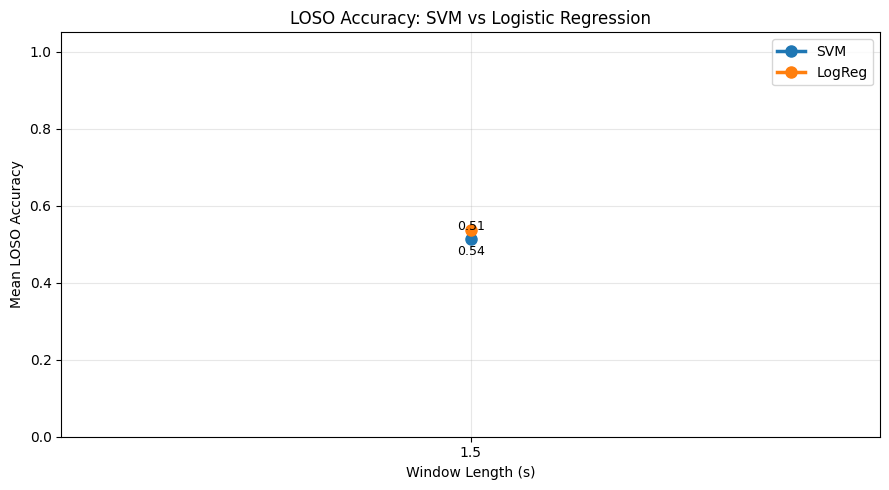

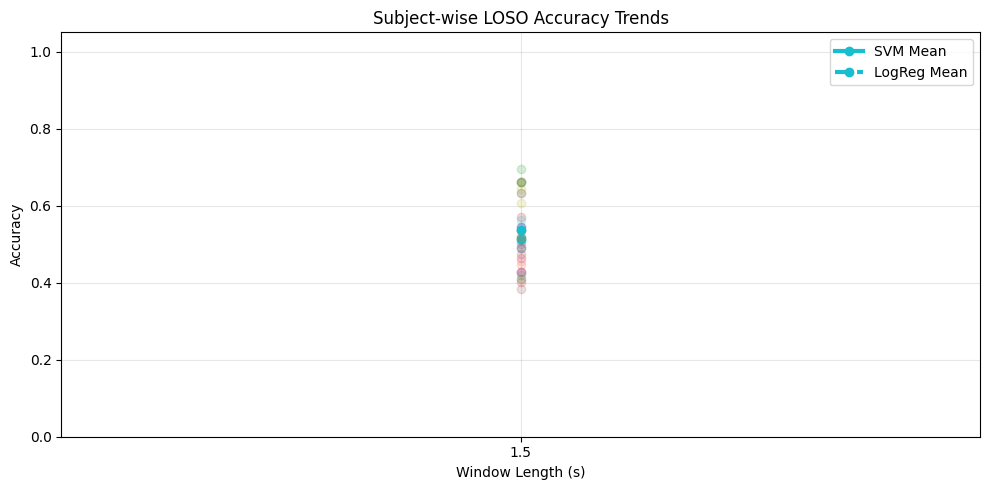


SUMMARY TABLE
   Window (s)  SVM Mean Acc  SVM Std  LogReg Mean Acc  LogReg Std
0         1.5         0.514    0.095            0.538       0.081

PER-SUBJECT ACCURACY TABLE
   Subject  SVM_1.5s  LogReg_1.5s
0       S1     0.509        0.545
1       S2     0.634        0.661
2       S3     0.696        0.661
3       S4     0.500        0.571
4       S5     0.429        0.491
5       S6     0.384        0.429
6       S7     0.411        0.429
7       S8     0.518        0.518
8       S9     0.661        0.661
9      S10     0.491        0.562
10     S11     0.634        0.661
11     S12     0.446        0.518
12     S13     0.420        0.411
13     S14     0.402        0.464
14     S15     0.545        0.545
15     S16     0.473        0.491
16     S17     0.429        0.455
17     S18     0.536        0.536
18     S19     0.643        0.607


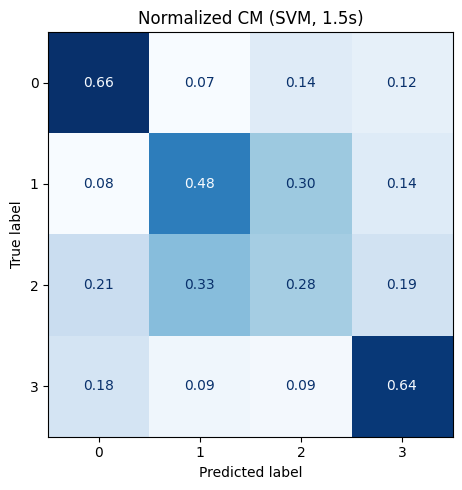

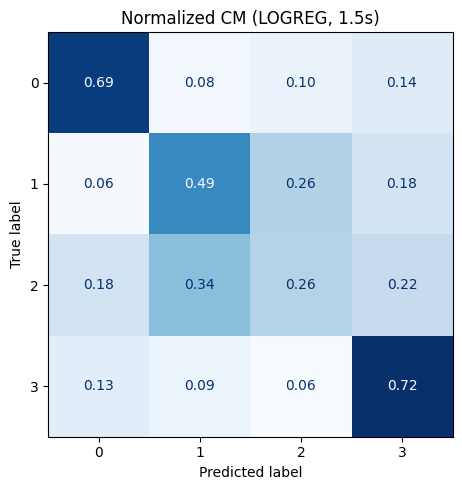


BEST WINDOWS
SVM    -> best window = 1.5 s | mean acc = 0.514 ± 0.095
LogReg -> best window = 1.5 s | mean acc = 0.538 ± 0.081


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import pandas as pd

# =========================================================
# SETTINGS
# =========================================================
window_lengths = [1.5]   # change as needed
fmin, fmax = 8, 30

classifier_list = ["svm", "logreg"]      # run both together
all_clf_results = {}

# =========================================================
# 1. RUN LOSO FOR BOTH CLASSIFIERS
# =========================================================
for clf_type in classifier_list:
    print("\n" + "=" * 80)
    print(f"Running classifier: {clf_type.upper()}")
    print("=" * 80)

    all_results = {}

    for win_len in window_lengths:
        step = 0.25 * win_len   # keep same as your current code

        print("-" * 60)
        print(f"Window length = {win_len} s | step = {step} s")
        print("-" * 60)

        results = cross_subject_riemann_tangent_windowed(
            subject_epochs,
            fmin=fmin,
            fmax=fmax,
            win_len=win_len,
            step=step,
            clf_type=clf_type
        )

        all_results[win_len] = results

    all_clf_results[clf_type] = all_results

# =========================================================
# 2. GET SORTED SUBJECT LIST
# =========================================================
example_per_acc = all_clf_results["svm"][window_lengths[0]]["per_subject_acc"]

subjects = sorted(
    example_per_acc.keys(),
    key=lambda s: int(s[1:]) if s[1:].isdigit() else s
)

# =========================================================
# 3. BUILD ACCURACY MATRICES
#    rows = subjects, cols = window lengths
# =========================================================
acc_matrix_svm = np.array([
    [all_clf_results["svm"][w]["per_subject_acc"][s] for w in window_lengths]
    for s in subjects
])

acc_matrix_logreg = np.array([
    [all_clf_results["logreg"][w]["per_subject_acc"][s] for w in window_lengths]
    for s in subjects
])

# =========================================================
# 4. COMPUTE MEAN ± STD ACROSS SUBJECTS
# =========================================================
mean_svm = acc_matrix_svm.mean(axis=0)
std_svm  = acc_matrix_svm.std(axis=0)

mean_log = acc_matrix_logreg.mean(axis=0)
std_log  = acc_matrix_logreg.std(axis=0)

# =========================================================
# 5. MAIN COMBINED LINE PLOT
#    SVM + LogReg in one graph with circular markers
# =========================================================
plt.figure(figsize=(9, 5))

plt.plot(window_lengths, mean_svm, marker='o', linewidth=2.5, markersize=8, label='SVM')
plt.fill_between(window_lengths, mean_svm - std_svm, mean_svm + std_svm, alpha=0.20)

plt.plot(window_lengths, mean_log, marker='o', linewidth=2.5, markersize=8, label='LogReg')
plt.fill_between(window_lengths, mean_log - std_log, mean_log + std_log, alpha=0.20)

for i, w in enumerate(window_lengths):
    plt.text(w, mean_svm[i] + 0.015, f"{mean_svm[i]:.2f}", ha='center', va='bottom', fontsize=9)
    plt.text(w, mean_log[i] - 0.04, f"{mean_log[i]:.2f}", ha='center', va='top', fontsize=9)

plt.xlabel("Window Length (s)")
plt.ylabel("Mean LOSO Accuracy")
plt.title("LOSO Accuracy: SVM vs Logistic Regression")
plt.xticks(window_lengths, [str(w) for w in window_lengths])
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# 6. OPTIONAL: SUBJECT-WISE LINES FOR BOTH CLASSIFIERS
# =========================================================
plt.figure(figsize=(10, 5))

for i in range(len(subjects)):
    plt.plot(window_lengths, acc_matrix_svm[i], marker='o', alpha=0.18, linewidth=1)

plt.plot(window_lengths, mean_svm, marker='o', linewidth=3, label='SVM Mean')

for i in range(len(subjects)):
    plt.plot(window_lengths, acc_matrix_logreg[i], marker='o', alpha=0.18, linewidth=1, linestyle='--')

plt.plot(window_lengths, mean_log, marker='o', linewidth=3, linestyle='--', label='LogReg Mean')

plt.xlabel("Window Length (s)")
plt.ylabel("Accuracy")
plt.title("Subject-wise LOSO Accuracy Trends")
plt.xticks(window_lengths, [str(w) for w in window_lengths])
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# 7. SUMMARY TABLE
# =========================================================
summary_rows = []

for i, w in enumerate(window_lengths):
    summary_rows.append({
        "Window (s)": w,
        "SVM Mean Acc": mean_svm[i],
        "SVM Std": std_svm[i],
        "LogReg Mean Acc": mean_log[i],
        "LogReg Std": std_log[i]
    })

summary_df = pd.DataFrame(summary_rows)
print("\nSUMMARY TABLE")
print(summary_df.round(3))

# =========================================================
# 8. PER-SUBJECT TABLE
# =========================================================
per_subject_df = pd.DataFrame({
    "Subject": subjects
})

for j, w in enumerate(window_lengths):
    per_subject_df[f"SVM_{w}s"] = acc_matrix_svm[:, j]
    per_subject_df[f"LogReg_{w}s"] = acc_matrix_logreg[:, j]

print("\nPER-SUBJECT ACCURACY TABLE")
print(per_subject_df.round(3))

# =========================================================
# 9. NORMALIZED CONFUSION MATRICES
#    (for each classifier and each window length)
# =========================================================
for clf_type in classifier_list:
    for w in window_lengths:
        cm = all_clf_results[clf_type][w]["overall_cm"]

        if "class_names" in all_clf_results[clf_type][w]:
            class_names = all_clf_results[clf_type][w]["class_names"]
        else:
            class_names = [str(i) for i in range(cm.shape[0])]

        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        cm_norm = np.nan_to_num(cm_norm)

        fig, ax = plt.subplots(figsize=(6, 5))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
        disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
        plt.title(f"Normalized CM ({clf_type.upper()}, {w}s)")
        plt.tight_layout()
        plt.show()

# =========================================================
# 10. BEST WINDOW PER CLASSIFIER
# =========================================================
best_idx_svm = np.argmax(mean_svm)
best_idx_log = np.argmax(mean_log)

print("\n" + "=" * 70)
print("BEST WINDOWS")
print("=" * 70)
print(f"SVM    -> best window = {window_lengths[best_idx_svm]} s | mean acc = {mean_svm[best_idx_svm]:.3f} ± {std_svm[best_idx_svm]:.3f}")
print(f"LogReg -> best window = {window_lengths[best_idx_log]} s | mean acc = {mean_log[best_idx_log]:.3f} ± {std_log[best_idx_log]:.3f}")

SVM 75% overlap , test overlap

Running for window length = 1.5 s | step = 0.375 s
Subjects: ['S1', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15', 'S16', 'S17', 'S18', 'S19', 'S2', 'S3', 'S4', 'S5', 'S6', 'S8', 'S9']

Testing on subject: S1
Train windows: 1904 | Test windows: 112
Channels: 121 | Samples/window: 750
Subject S1 window-accuracy: 0.545
Confusion matrix:
[[16  0  2 10]
 [ 0  3 24  1]
 [ 0  3 22  3]
 [ 0  1  7 20]]

Testing on subject: S10
Train windows: 1904 | Test windows: 112
Channels: 121 | Samples/window: 750
Subject S10 window-accuracy: 0.482
Confusion matrix:
[[20  6  1  1]
 [ 0 25  3  0]
 [ 0 24  2  2]
 [13  5  3  7]]

Testing on subject: S11
Train windows: 1904 | Test windows: 112
Channels: 121 | Samples/window: 750
Subject S11 window-accuracy: 0.634
Confusion matrix:
[[15  0  2 11]
 [ 0  6 14  8]
 [ 1  0 23  4]
 [ 0  0  1 27]]

Testing on subject: S12
Train windows: 1904 | Test windows: 112
Channels: 121 | Samples/window: 750
Subject S12 window-accuracy: 0.509
Confusion matrix:
[[21  0  7  0]
 [ 0  3 

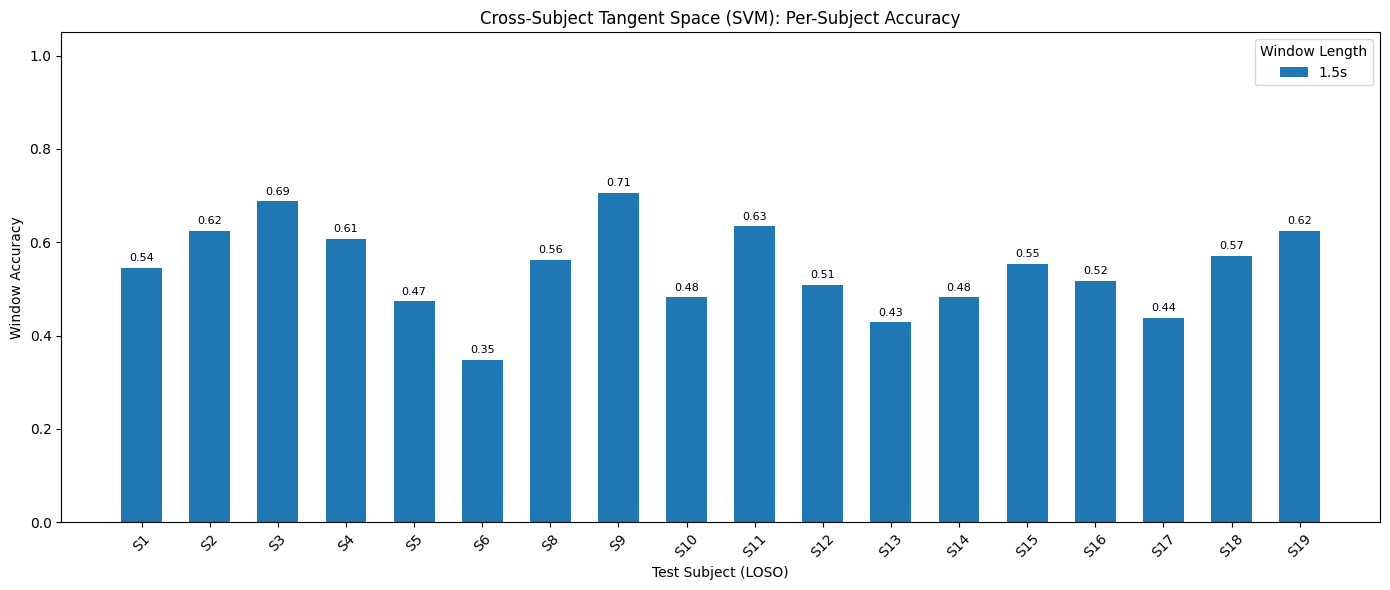

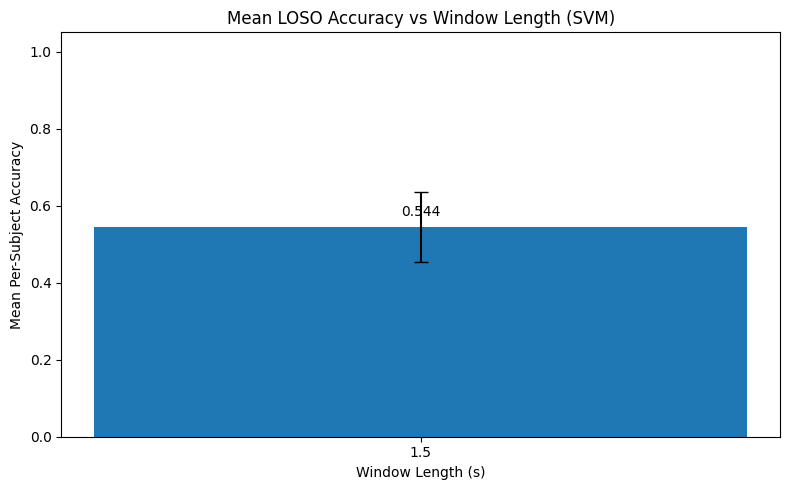

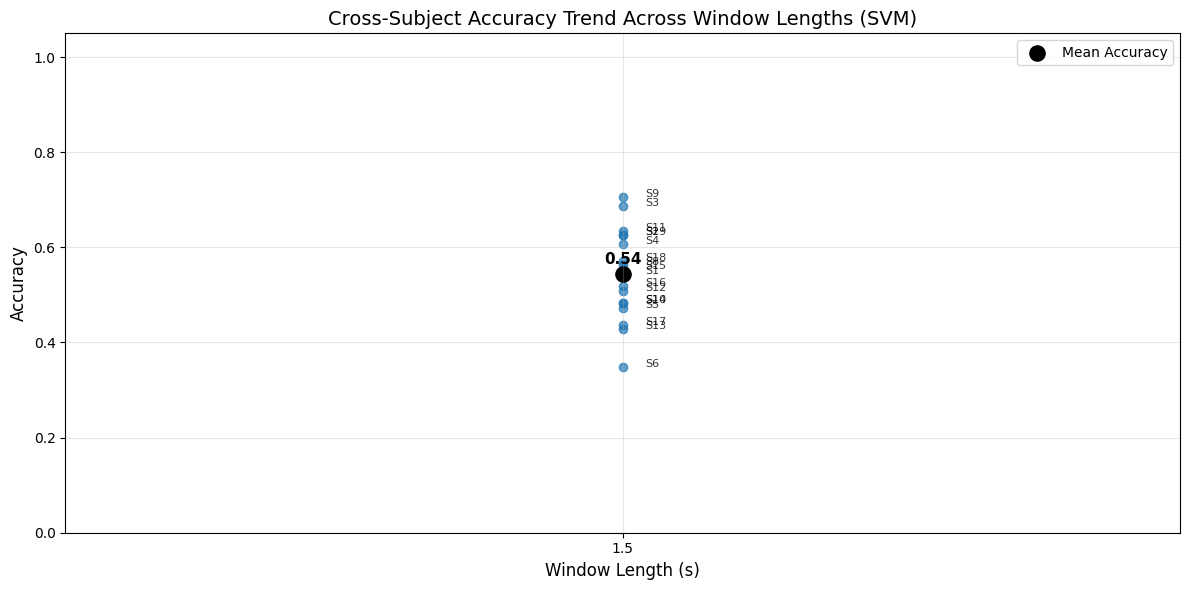

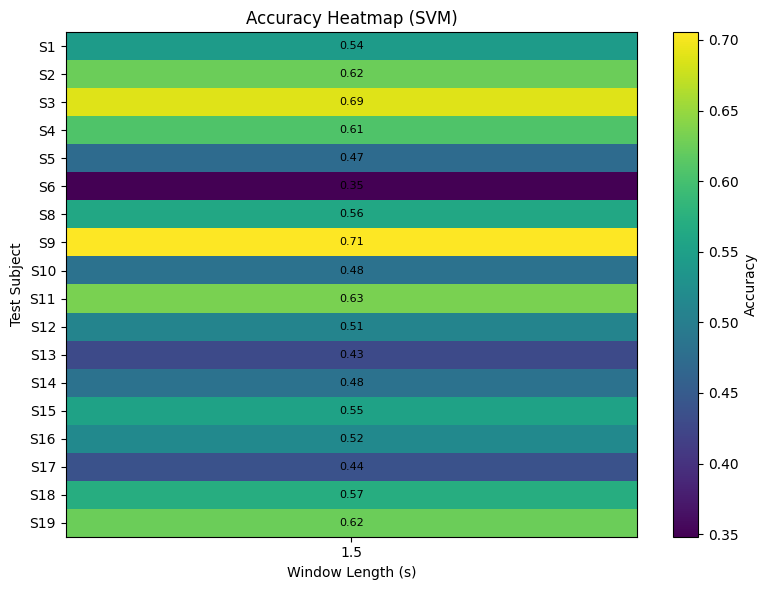

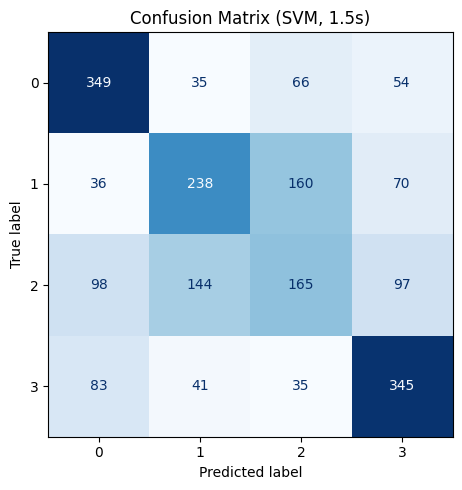

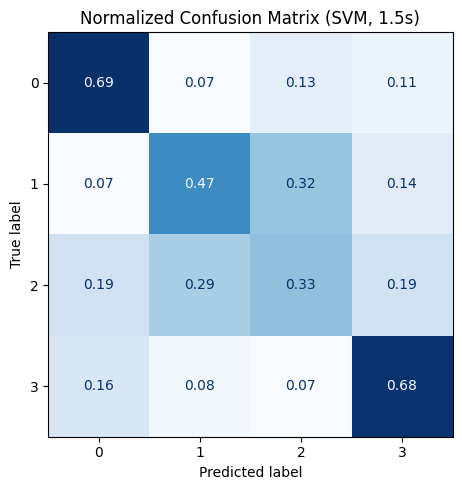


SUMMARY

Window length = 1.5s
Overall accuracy          : 0.544
Mean per-subject accuracy : 0.544
Std per-subject accuracy  : 0.091
Overall confusion matrix:
[[349  35  66  54]
 [ 36 238 160  70]
 [ 98 144 165  97]
 [ 83  41  35 345]]


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. Run LOSO cross-subject tangent-space classification
#    for multiple non-overlapping window lengths
# =========================================================
window_lengths = [1.5]
clf_type = "svm"   # or "logreg"

all_results = {}

for win_len in window_lengths:
    print("=" * 60)
    print(f"Running for window length = {win_len} s | step = {0.25 * win_len} s")
    print("=" * 60)

    results = cross_subject_riemann_tangent_windowed(
        subject_epochs,
        fmin=8, fmax=30,
        win_len=win_len,
        step=0.25 * win_len,     # 60% overlap
        clf_type=clf_type
    )

    all_results[win_len] = results

# =========================================================
# 2. Get sorted subject list
# =========================================================
example_per_acc = all_results[window_lengths[0]]["per_subject_acc"]
subjects = sorted(
    example_per_acc.keys(),
    key=lambda s: int(s[1:]) if s[1:].isdigit() else s
)

# Build accuracy matrix: rows = subjects, cols = window lengths
acc_matrix = np.array([
    [all_results[w]["per_subject_acc"][s] for w in window_lengths]
    for s in subjects
])

# =========================================================
# 3. Grouped bar plot: per-subject accuracy for all window lengths
# =========================================================
x = np.arange(len(subjects))
n_groups = len(window_lengths)

plt.figure(figsize=(14, 6))

if n_groups == 1:
    bar_width = 0.6
    offsets = x
else:
    bar_width = 0.8 / n_groups

for j, w in enumerate(window_lengths):
    if n_groups == 1:
        offsets = x
    else:
        offsets = x - (n_groups - 1) / 2 * bar_width + j * bar_width

    bars = plt.bar(offsets, acc_matrix[:, j],
                   width=bar_width,
                   label=f"{w}s")

    for i, acc in enumerate(acc_matrix[:, j]):
        plt.text(offsets[i], acc + 0.01, f"{acc:.2f}",
                 ha="center", va="bottom", fontsize=8)

plt.xlabel("Test Subject (LOSO)")
plt.ylabel("Window Accuracy")
plt.title(f"Cross-Subject Tangent Space ({clf_type.upper()}): Per-Subject Accuracy")
plt.xticks(x, subjects, rotation=45)
plt.ylim(0, 1.05)
plt.legend(title="Window Length")
plt.tight_layout()
plt.show()

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# =========================================================
# 4. Mean accuracy across subjects for each window length
# =========================================================
mean_accs = acc_matrix.mean(axis=0)
std_accs  = acc_matrix.std(axis=0)

# Make sure x-axis works for both 1 and many window lengths
xw = np.arange(len(window_lengths))
window_labels = [str(w) for w in window_lengths]

plt.figure(figsize=(8, 5))
bars = plt.bar(xw, mean_accs, yerr=std_accs, capsize=5, width=0.6)

for i, acc in enumerate(mean_accs):
    plt.text(xw[i], acc + 0.02, f"{acc:.3f}",
             ha="center", va="bottom", fontsize=10)

plt.xticks(xw, window_labels)
plt.xlabel("Window Length (s)")
plt.ylabel("Mean Per-Subject Accuracy")
plt.title(f"Mean LOSO Accuracy vs Window Length ({clf_type.upper()})")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()


# =========================================================
# 5. Line plot: subject-wise trend across window lengths
# =========================================================
plt.figure(figsize=(12, 6))

if len(window_lengths) == 1:
    # With only one window length, line plot is not meaningful.
    # So use a scatter-style visualization instead.
    x_single = np.zeros(len(subjects))

    plt.scatter(x_single, acc_matrix[:, 0], alpha=0.7)

    mean_acc = acc_matrix.mean(axis=0)
    plt.scatter([0], [mean_acc[0]], s=120, color='black', label="Mean Accuracy")

    for i, subj in enumerate(subjects):
        plt.text(0.02, acc_matrix[i, 0], subj, fontsize=8, alpha=0.8)

    plt.text(0, mean_acc[0] + 0.02,
             f"{mean_acc[0]:.2f}",
             ha='center', fontsize=11, fontweight='bold')

    plt.xticks([0], [str(window_lengths[0])])
    plt.xlim(-0.5, 0.5)

else:
    # Plot individual subjects
    for i, subj in enumerate(subjects):
        plt.plot(window_lengths, acc_matrix[i],
                 marker='o',
                 alpha=0.35,
                 linewidth=1)

    # Plot mean accuracy
    mean_acc = acc_matrix.mean(axis=0)
    plt.plot(window_lengths, mean_acc,
             marker='o',
             color='black',
             linewidth=3,
             label="Mean Accuracy")

    # Annotate mean values only
    for j, w in enumerate(window_lengths):
        plt.text(w, mean_acc[j] + 0.015,
                 f"{mean_acc[j]:.2f}",
                 ha='center',
                 fontsize=11,
                 fontweight='bold')

plt.xlabel("Window Length (s)", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title(f"Cross-Subject Accuracy Trend Across Window Lengths ({clf_type.upper()})", fontsize=14)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# =========================================================
# 6. Heatmap: subjects x window lengths
# =========================================================
plt.figure(figsize=(8, 6))
im = plt.imshow(acc_matrix, aspect='auto', interpolation='nearest')

plt.colorbar(im, label="Accuracy")
plt.xticks(np.arange(len(window_lengths)), [str(w) for w in window_lengths])
plt.yticks(np.arange(len(subjects)), subjects)
plt.xlabel("Window Length (s)")
plt.ylabel("Test Subject")
plt.title(f"Accuracy Heatmap ({clf_type.upper()})")

# annotate each cell
for i in range(acc_matrix.shape[0]):
    for j in range(acc_matrix.shape[1]):
        plt.text(j, i, f"{acc_matrix[i, j]:.2f}",
                 ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()


# =========================================================
# 7. Confusion matrix for each window length
# =========================================================
# Assumes each all_results[w] contains:
#   all_results[w]["overall_cm"]
# and optionally:
#   all_results[w]["class_names"]

for w in window_lengths:
    cm = all_results[w]["overall_cm"]

    if "class_names" in all_results[w]:
        class_names = all_results[w]["class_names"]
    else:
        class_names = [str(i) for i in range(cm.shape[0])]

    # Raw confusion matrix
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    plt.title(f"Confusion Matrix ({clf_type.upper()}, {w}s)")
    plt.tight_layout()
    plt.show()

    # Normalized confusion matrix
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)

    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
    plt.title(f"Normalized Confusion Matrix ({clf_type.upper()}, {w}s)")
    plt.tight_layout()
    plt.show()


# =========================================================
# 8. Print summary
# =========================================================
print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)

for w in window_lengths:
    per_acc = all_results[w]["per_subject_acc"]
    accs = [per_acc[s] for s in subjects]

    print(f"\nWindow length = {w}s")
    print(f"Overall accuracy          : {all_results[w]['overall_acc']:.3f}")
    print(f"Mean per-subject accuracy : {np.mean(accs):.3f}")
    print(f"Std per-subject accuracy  : {np.std(accs):.3f}")

    if "overall_cm" in all_results[w]:
        cm = all_results[w]["overall_cm"]
        print("Overall confusion matrix:")
        print(cm)

Logreg 75% overlap , test overlap

Running for window length = 1.5 s | step = 0.375 s
Subjects: ['S1', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15', 'S16', 'S17', 'S18', 'S19', 'S2', 'S3', 'S4', 'S5', 'S6', 'S8', 'S9']

Testing on subject: S1
Train windows: 1904 | Test windows: 112
Channels: 121 | Samples/window: 750
Subject S1 window-accuracy: 0.562
Confusion matrix:
[[14  0  4 10]
 [ 0  8 20  0]
 [ 0  5 20  3]
 [ 0  3  4 21]]

Testing on subject: S10
Train windows: 1904 | Test windows: 112
Channels: 121 | Samples/window: 750
Subject S10 window-accuracy: 0.589
Confusion matrix:
[[23  2  0  3]
 [ 0 25  3  0]
 [ 2 23  1  2]
 [ 5  6  0 17]]

Testing on subject: S11
Train windows: 1904 | Test windows: 112
Channels: 121 | Samples/window: 750
Subject S11 window-accuracy: 0.625
Confusion matrix:
[[12  0  1 15]
 [ 0  8 12  8]
 [ 0  0 22  6]
 [ 0  0  0 28]]

Testing on subject: S12
Train windows: 1904 | Test windows: 112
Channels: 121 | Samples/window: 750
Subject S12 window-accuracy: 0.518
Confusion matrix:
[[19  0  7  2]
 [ 0  2 

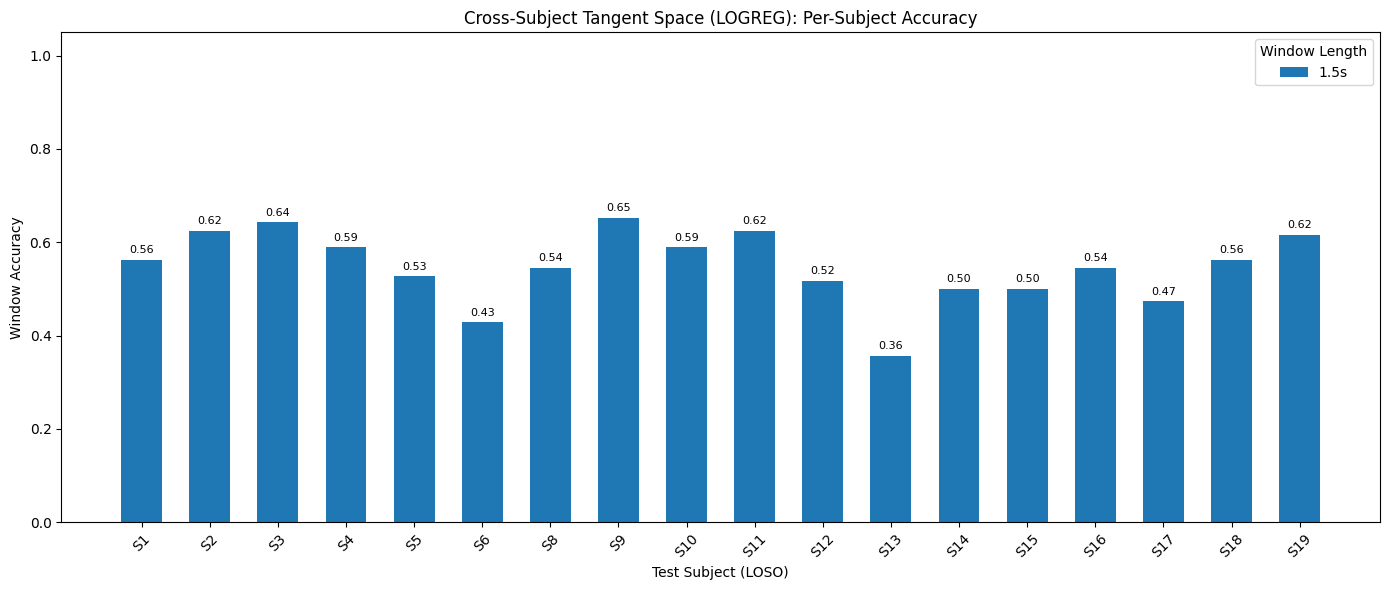

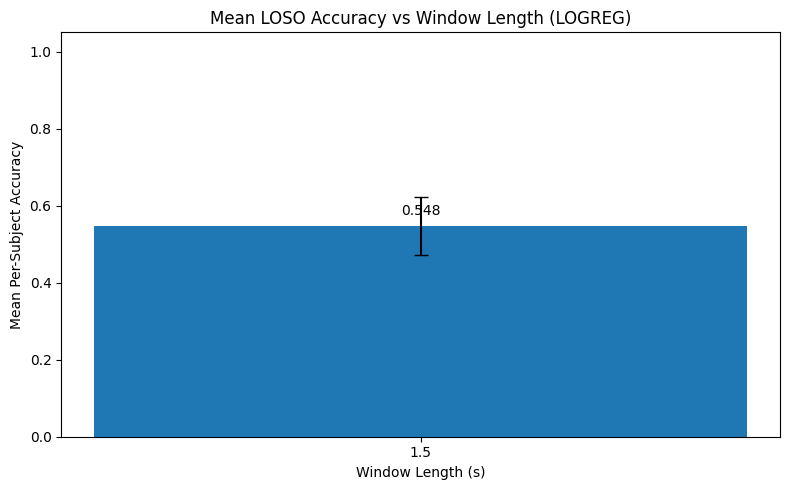

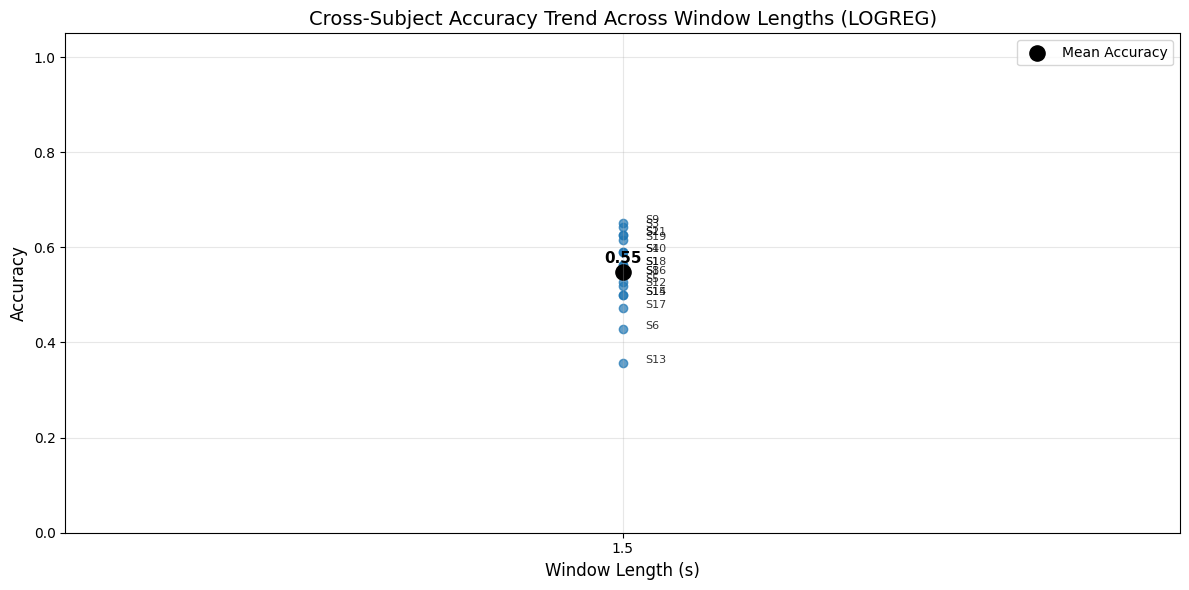

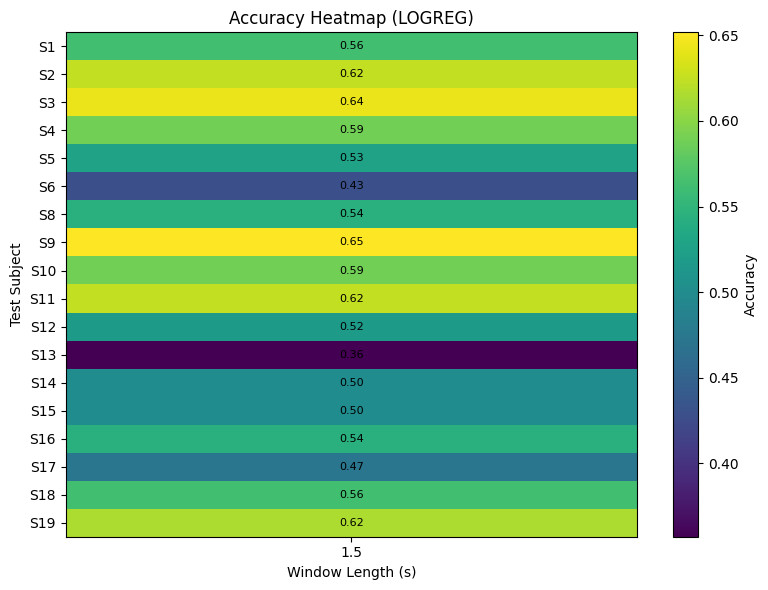

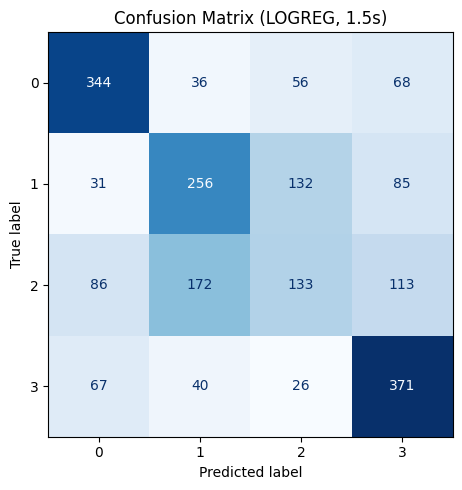

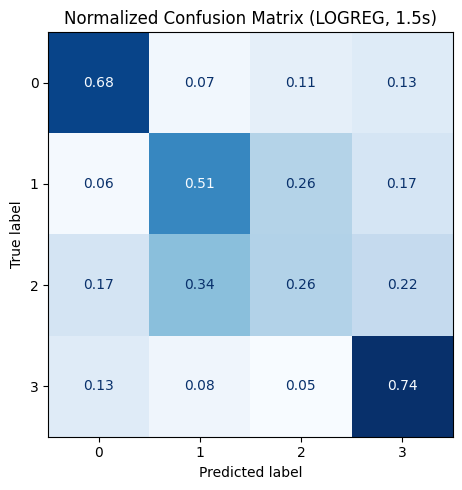


SUMMARY

Window length = 1.5s
Overall accuracy          : 0.548
Mean per-subject accuracy : 0.548
Std per-subject accuracy  : 0.075
Overall confusion matrix:
[[344  36  56  68]
 [ 31 256 132  85]
 [ 86 172 133 113]
 [ 67  40  26 371]]


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1. Run LOSO cross-subject tangent-space classification
#    for multiple non-overlapping window lengths
# =========================================================
window_lengths = [1.5]
clf_type = "logreg"   # or "svm"

all_results = {}

for win_len in window_lengths:
    print("=" * 60)
    print(f"Running for window length = {win_len} s | step = {0.25 * win_len} s")
    print("=" * 60)

    results = cross_subject_riemann_tangent_windowed(
        subject_epochs,
        fmin=8, fmax=30,
        win_len=win_len,
        step=0.25 * win_len,     # 60% overlap
        clf_type=clf_type
    )

    all_results[win_len] = results

# =========================================================
# 2. Get sorted subject list
# =========================================================
example_per_acc = all_results[window_lengths[0]]["per_subject_acc"]
subjects = sorted(
    example_per_acc.keys(),
    key=lambda s: int(s[1:]) if s[1:].isdigit() else s
)

# Build accuracy matrix: rows = subjects, cols = window lengths
acc_matrix = np.array([
    [all_results[w]["per_subject_acc"][s] for w in window_lengths]
    for s in subjects
])

# =========================================================
# 3. Grouped bar plot: per-subject accuracy for all window lengths
# =========================================================
x = np.arange(len(subjects))
n_groups = len(window_lengths)

plt.figure(figsize=(14, 6))

if n_groups == 1:
    bar_width = 0.6
    offsets = x
else:
    bar_width = 0.8 / n_groups

for j, w in enumerate(window_lengths):
    if n_groups == 1:
        offsets = x
    else:
        offsets = x - (n_groups - 1) / 2 * bar_width + j * bar_width

    bars = plt.bar(offsets, acc_matrix[:, j],
                   width=bar_width,
                   label=f"{w}s")

    for i, acc in enumerate(acc_matrix[:, j]):
        plt.text(offsets[i], acc + 0.01, f"{acc:.2f}",
                 ha="center", va="bottom", fontsize=8)

plt.xlabel("Test Subject (LOSO)")
plt.ylabel("Window Accuracy")
plt.title(f"Cross-Subject Tangent Space ({clf_type.upper()}): Per-Subject Accuracy")
plt.xticks(x, subjects, rotation=45)
plt.ylim(0, 1.05)
plt.legend(title="Window Length")
plt.tight_layout()
plt.show()

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# =========================================================
# 4. Mean accuracy across subjects for each window length
# =========================================================
mean_accs = acc_matrix.mean(axis=0)
std_accs  = acc_matrix.std(axis=0)

# Make sure x-axis works for both 1 and many window lengths
xw = np.arange(len(window_lengths))
window_labels = [str(w) for w in window_lengths]

plt.figure(figsize=(8, 5))
bars = plt.bar(xw, mean_accs, yerr=std_accs, capsize=5, width=0.6)

for i, acc in enumerate(mean_accs):
    plt.text(xw[i], acc + 0.02, f"{acc:.3f}",
             ha="center", va="bottom", fontsize=10)

plt.xticks(xw, window_labels)
plt.xlabel("Window Length (s)")
plt.ylabel("Mean Per-Subject Accuracy")
plt.title(f"Mean LOSO Accuracy vs Window Length ({clf_type.upper()})")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()


# =========================================================
# 5. Line plot: subject-wise trend across window lengths
# =========================================================
plt.figure(figsize=(12, 6))

if len(window_lengths) == 1:
    # With only one window length, line plot is not meaningful.
    # So use a scatter-style visualization instead.
    x_single = np.zeros(len(subjects))

    plt.scatter(x_single, acc_matrix[:, 0], alpha=0.7)

    mean_acc = acc_matrix.mean(axis=0)
    plt.scatter([0], [mean_acc[0]], s=120, color='black', label="Mean Accuracy")

    for i, subj in enumerate(subjects):
        plt.text(0.02, acc_matrix[i, 0], subj, fontsize=8, alpha=0.8)

    plt.text(0, mean_acc[0] + 0.02,
             f"{mean_acc[0]:.2f}",
             ha='center', fontsize=11, fontweight='bold')

    plt.xticks([0], [str(window_lengths[0])])
    plt.xlim(-0.5, 0.5)

else:
    # Plot individual subjects
    for i, subj in enumerate(subjects):
        plt.plot(window_lengths, acc_matrix[i],
                 marker='o',
                 alpha=0.35,
                 linewidth=1)

    # Plot mean accuracy
    mean_acc = acc_matrix.mean(axis=0)
    plt.plot(window_lengths, mean_acc,
             marker='o',
             color='black',
             linewidth=3,
             label="Mean Accuracy")

    # Annotate mean values only
    for j, w in enumerate(window_lengths):
        plt.text(w, mean_acc[j] + 0.015,
                 f"{mean_acc[j]:.2f}",
                 ha='center',
                 fontsize=11,
                 fontweight='bold')

plt.xlabel("Window Length (s)", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title(f"Cross-Subject Accuracy Trend Across Window Lengths ({clf_type.upper()})", fontsize=14)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# =========================================================
# 6. Heatmap: subjects x window lengths
# =========================================================
plt.figure(figsize=(8, 6))
im = plt.imshow(acc_matrix, aspect='auto', interpolation='nearest')

plt.colorbar(im, label="Accuracy")
plt.xticks(np.arange(len(window_lengths)), [str(w) for w in window_lengths])
plt.yticks(np.arange(len(subjects)), subjects)
plt.xlabel("Window Length (s)")
plt.ylabel("Test Subject")
plt.title(f"Accuracy Heatmap ({clf_type.upper()})")

# annotate each cell
for i in range(acc_matrix.shape[0]):
    for j in range(acc_matrix.shape[1]):
        plt.text(j, i, f"{acc_matrix[i, j]:.2f}",
                 ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()


# =========================================================
# 7. Confusion matrix for each window length
# =========================================================
# Assumes each all_results[w] contains:
#   all_results[w]["overall_cm"]
# and optionally:
#   all_results[w]["class_names"]

for w in window_lengths:
    cm = all_results[w]["overall_cm"]

    if "class_names" in all_results[w]:
        class_names = all_results[w]["class_names"]
    else:
        class_names = [str(i) for i in range(cm.shape[0])]

    # Raw confusion matrix
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    plt.title(f"Confusion Matrix ({clf_type.upper()}, {w}s)")
    plt.tight_layout()
    plt.show()

    # Normalized confusion matrix
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cm_norm = np.nan_to_num(cm_norm)

    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
    disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
    plt.title(f"Normalized Confusion Matrix ({clf_type.upper()}, {w}s)")
    plt.tight_layout()
    plt.show()


# =========================================================
# 8. Print summary
# =========================================================
print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)

for w in window_lengths:
    per_acc = all_results[w]["per_subject_acc"]
    accs = [per_acc[s] for s in subjects]

    print(f"\nWindow length = {w}s")
    print(f"Overall accuracy          : {all_results[w]['overall_acc']:.3f}")
    print(f"Mean per-subject accuracy : {np.mean(accs):.3f}")
    print(f"Std per-subject accuracy  : {np.std(accs):.3f}")

    if "overall_cm" in all_results[w]:
        cm = all_results[w]["overall_cm"]
        print("Overall confusion matrix:")
        print(cm)

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from pyriemann.estimation import Covariances
from pyriemann.utils.mean import mean_covariance
from pyriemann.utils.distance import distance_riemann

def plot_class_distance_heatmap(epochs, fmin=8, fmax=30, title_prefix=""):
    """
    epochs: MNE Epochs with 2 classes labeled as 1,2,3,4 in events[:,2]
            e.g. 1=ISLO, 1=ISLT, 2=ISRO, 2=ISRT
    """

    # 1) Band-pass filter
    ep = epochs.copy().filter(fmin, fmax)

    # 2) Extract data and labels
    X = ep.get_data()             # (n_trials, n_ch, n_times)
    y = ep.events[:, 2]           # e.g. {1,2,3,4}

    classes = np.unique(y)
    print("Classes present:", classes)

    # 3) Covariance matrices for each trial
    #    → shape (n_trials, n_ch, n_ch)
    covs = Covariances(estimator='oas').fit_transform(X)

    # 4) Compute Riemannian class-mean covariance for each class
    class_means = {}
    for c in classes:
        cov_c = covs[y == c]                    # (n_c_trials, n_ch, n_ch)
        if cov_c.shape[0] < 2:
            print(f"⚠ Class {c} has < 2 trials, mean may be unstable.")
        class_means[c] = mean_covariance(cov_c, metric='riemann')

    # 5) Build distance matrix between class means
    n_cls = len(classes)
    D = np.zeros((n_cls, n_cls))

    for i, ci in enumerate(classes):
        for j, cj in enumerate(classes):
            D[i, j] = distance_riemann(class_means[ci], class_means[cj])

    # 6) Plot heatmap
    plt.figure(figsize=(6, 5))
    im = plt.imshow(D, origin='lower', cmap='viridis')
    plt.colorbar(im, label='Riemannian distance')
    plt.xticks(range(n_cls), [f"class {c}" for c in classes])
    plt.yticks(range(n_cls), [f"class {c}" for c in classes])
    plt.title(f"{title_prefix} Class-wise Riemannian distances")
    plt.tight_layout()
    plt.show()

    return D, classes


Classes present: [1 2 3 4]


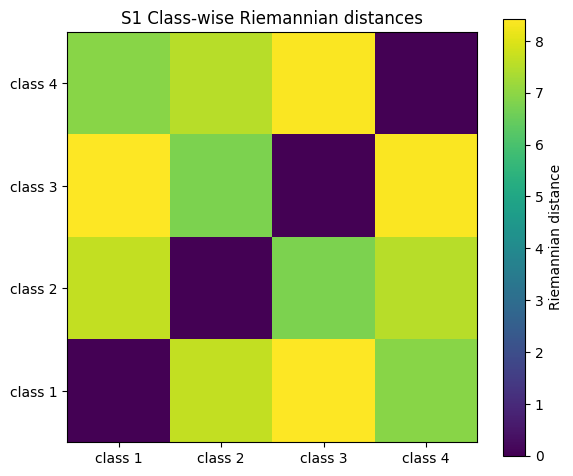

In [9]:
D_s1, cls_s1 = plot_class_distance_heatmap(subject_epochs["S1"],
                                           fmin=8, fmax=30,
                                           title_prefix="S1")


Classes present: [1 2 3 4]


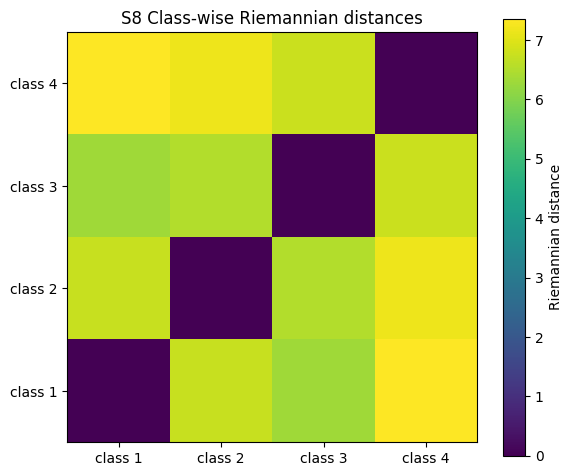

In [10]:
D_s1, cls_s1 = plot_class_distance_heatmap(subject_epochs["S8"],
                                           fmin=8, fmax=30,
                                           title_prefix="S8")


Classes present: [1 2 3 4]


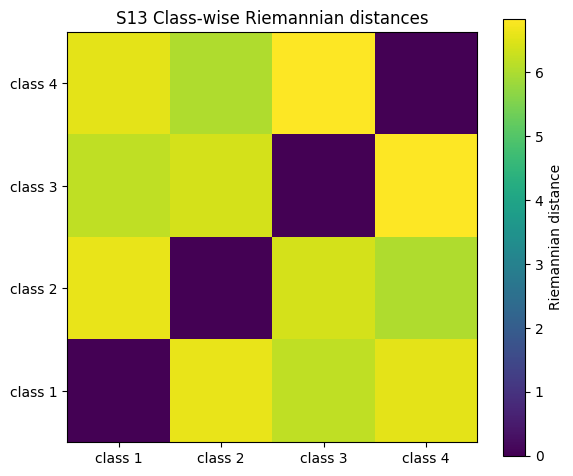

In [11]:
D_s1, cls_s1 = plot_class_distance_heatmap(subject_epochs["S13"],
                                           fmin=8, fmax=30,
                                           title_prefix="S13")


In [12]:
import numpy as np

from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold


def within_subject_riemann_tangent_windowed(
    epochs,
    fmin=8, fmax=30,
    win_len=1.0,
    step=1.0,
    n_splits=5,
    clf_type="logreg",
    vote_trials=True
):
    """
    Leakage-free within-subject Riemannian tangent-space classification.

    Splits by TRIAL first, then assigns all windows from a trial
    to either train or test.

    Parameters
    ----------
    epochs : mne.Epochs
        One subject's epochs
    fmin, fmax : float
        Bandpass range
    win_len, step : float
        Window length and step in seconds
    n_splits : int
        Number of CV folds over trials
    clf_type : str
        "logreg" or "svm"
    vote_trials : bool
        If True, also compute trial-level accuracy by majority vote
        across windows in each test trial

    Returns
    -------
    dict with fold accuracies, overall window accuracy,
    confusion matrix, and optional trial-vote accuracy
    """

    # -----------------------------------
    # 1. Window the data, keeping trial IDs
    # -----------------------------------
    Xw, yw, tid = epochs_to_Xy_windowed(
        epochs,
        fmin=fmin, fmax=fmax,
        win_len=win_len,
        step=step
    )

    # -----------------------------------
    # 2. Build trial-level labels
    # -----------------------------------
    unique_trials = np.unique(tid)

    # one label per trial
    y_trial = np.array([yw[tid == tr][0] for tr in unique_trials])

    # safety check
    class_counts = np.unique(y_trial, return_counts=True)[1]
    min_class_trials = class_counts.min()

    if n_splits > min_class_trials:
        raise ValueError(
            f"n_splits={n_splits} is too large. "
            f"Smallest class has only {min_class_trials} trials."
        )

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    fold_acc = []
    all_true_win, all_pred_win = [], []

    fold_trial_acc = []
    all_true_trial, all_pred_trial = [], []

    # -----------------------------------
    # 3. CV over trials, not windows
    # -----------------------------------
    for fold, (train_trial_idx, test_trial_idx) in enumerate(skf.split(unique_trials, y_trial), 1):

        train_trials = unique_trials[train_trial_idx]
        test_trials = unique_trials[test_trial_idx]

        # select windows belonging to train/test trials
        train_mask = np.isin(tid, train_trials)
        test_mask = np.isin(tid, test_trials)

        X_train, X_test = Xw[train_mask], Xw[test_mask]
        y_train, y_test = yw[train_mask], yw[test_mask]
        tid_test = tid[test_mask]

        # -----------------------------
        # 4. Riemannian pipeline
        # -----------------------------
        cov = Covariances(estimator="oas")
        cov_train = cov.fit_transform(X_train)
        cov_test = cov.transform(X_test)

        ts = TangentSpace(metric="riemann")
        X_train_tan = ts.fit_transform(cov_train)
        X_test_tan = ts.transform(cov_test)

        scaler = StandardScaler()
        X_train_tan = scaler.fit_transform(X_train_tan)
        X_test_tan = scaler.transform(X_test_tan)

        if clf_type == "logreg":
            clf = LogisticRegression(
                penalty="l2",
                solver="lbfgs",
                max_iter=1000,
                class_weight="balanced"
            )
        elif clf_type == "svm":
            clf = SVC(
                kernel="linear",
                C=1.0,
                class_weight="balanced"
            )
        else:
            raise ValueError("clf_type must be 'logreg' or 'svm'")

        clf.fit(X_train_tan, y_train)
        y_pred = clf.predict(X_test_tan)

        # -----------------------------
        # 5. Window-level accuracy
        # -----------------------------
        win_acc = accuracy_score(y_test, y_pred)
        fold_acc.append(win_acc)

        all_true_win.extend(y_test)
        all_pred_win.extend(y_pred)

        # -----------------------------
        # 6. Optional trial-level voting
        # -----------------------------
        if vote_trials:
            test_trial_ids_unique = np.unique(tid_test)

            trial_true = []
            trial_pred = []

            for tr in test_trial_ids_unique:
                tr_mask = (tid_test == tr)

                true_label = y_test[tr_mask][0]

                # majority vote across windows of this trial
                pred_labels = y_pred[tr_mask]
                vals, counts = np.unique(pred_labels, return_counts=True)
                pred_label = vals[np.argmax(counts)]

                trial_true.append(true_label)
                trial_pred.append(pred_label)

            trial_acc = accuracy_score(trial_true, trial_pred)
            fold_trial_acc.append(trial_acc)

            all_true_trial.extend(trial_true)
            all_pred_trial.extend(trial_pred)

    # -----------------------------------
    # 7. Return results
    # -----------------------------------
    results = {
        "fold_acc_window": fold_acc,
        "mean_acc_window": np.mean(fold_acc),
        "std_acc_window": np.std(fold_acc),
        "overall_acc_window": accuracy_score(all_true_win, all_pred_win),
        "overall_cm_window": confusion_matrix(all_true_win, all_pred_win),
    }

    if vote_trials:
        results.update({
            "fold_acc_trial": fold_trial_acc,
            "mean_acc_trial": np.mean(fold_trial_acc),
            "std_acc_trial": np.std(fold_trial_acc),
            "overall_acc_trial": accuracy_score(all_true_trial, all_pred_trial),
            "overall_cm_trial": confusion_matrix(all_true_trial, all_pred_trial),
        })

    return results

svm_75% overlap_ with_trial_index_so_no_leakage

In [13]:
import numpy as np
import matplotlib.pyplot as plt

window_lengths = [1.0]
clf_type = "svm"

within_results = {}

for win_len in window_lengths:

    print("=" * 60)
    print(f"Running window length = {win_len}")
    print("=" * 60)

    within_results[win_len] = {}

    for subj, epochs in subject_epochs.items():

        print(f"Subject: {subj}")

        res = within_subject_riemann_tangent_windowed(
            epochs,                     # <-- pass epochs, not dict
            fmin=8, fmax=30,
            win_len=win_len,
            step=0.25*win_len,
            n_splits=4,
            clf_type=clf_type
        )

        within_results[win_len][subj] = res

Running window length = 1.0
Subject: S1
Subject: S2
Subject: S3
Subject: S4
Subject: S5
Subject: S6
Subject: S8
Subject: S9
Subject: S10
Subject: S11
Subject: S12
Subject: S13
Subject: S14
Subject: S15
Subject: S16
Subject: S17
Subject: S18
Subject: S19


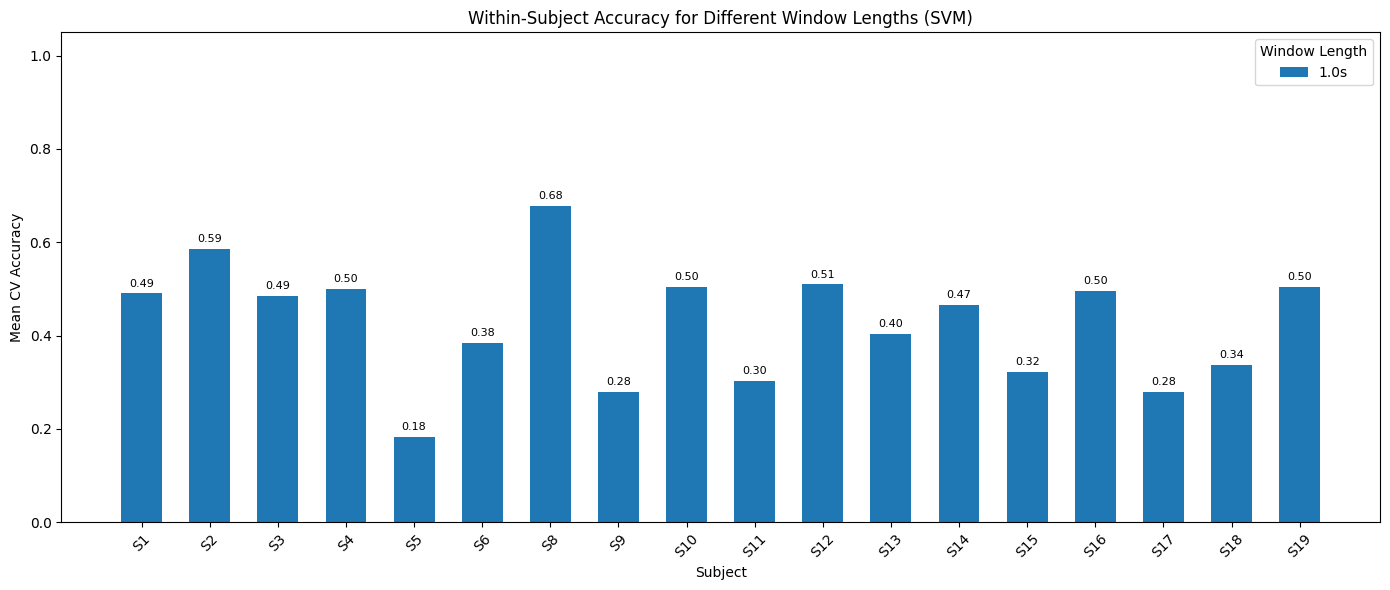

In [14]:
subjects = sorted(subject_epochs.keys(),
                  key=lambda s: int(s[1:]) if s[1:].isdigit() else s)

acc_matrix = np.array([
    [within_results[w][s]["mean_acc_window"] for w in window_lengths]
    for s in subjects
])

x = np.arange(len(subjects))
n_groups = len(window_lengths)

plt.figure(figsize=(14, 6))

# Adaptive bar width
if n_groups == 1:
    bar_width = 0.6
else:
    bar_width = 0.8 / n_groups  # total group width = 0.8

for j, w in enumerate(window_lengths):

    if n_groups == 1:
        offsets = x
    else:
        offsets = x - (n_groups - 1) / 2 * bar_width + j * bar_width

    vals = acc_matrix[:, j]

    plt.bar(offsets, vals,
            width=bar_width,
            label=f"{w}s")

    # value labels
    for i, acc in enumerate(vals):
        plt.text(offsets[i], acc + 0.01, f"{acc:.2f}",
                 ha="center", va="bottom", fontsize=8)

plt.xlabel("Subject")
plt.ylabel("Mean CV Accuracy")
plt.title(f"Within-Subject Accuracy for Different Window Lengths ({clf_type.upper()})")

# IMPORTANT: ticks must be centered at x
plt.xticks(x, subjects, rotation=45)

plt.ylim(0, 1.05)
plt.legend(title="Window Length")
plt.tight_layout()
plt.show()

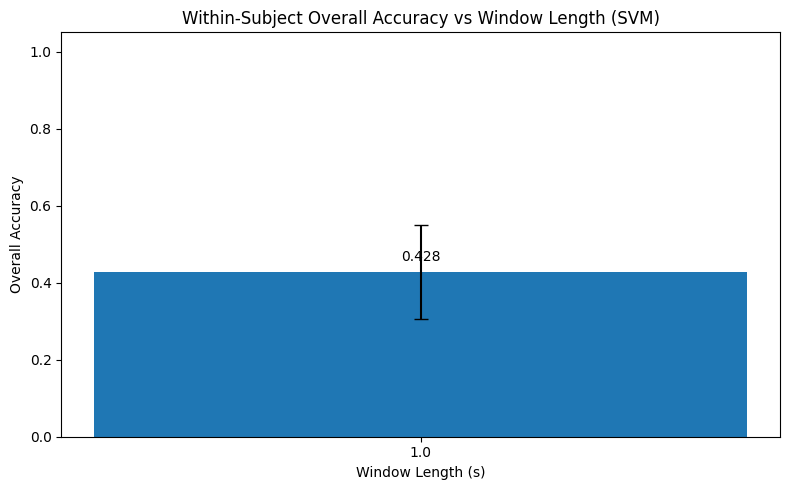

In [15]:
overall_accs = []
overall_stds = []

for w in window_lengths:
    subj_overall_accs = [
        within_results[w][subj]["mean_acc_window"]
        for subj in within_results[w]
    ]
    overall_accs.append(np.mean(subj_overall_accs))
    overall_stds.append(np.std(subj_overall_accs))


# Use numeric x positions (important for consistency)
xw = np.arange(len(window_lengths))
window_labels = [str(w) for w in window_lengths]

plt.figure(figsize=(8, 5))

bars = plt.bar(xw,
               overall_accs,
               yerr=overall_stds,
               capsize=5,
               width=0.6)

# value labels
for i, acc in enumerate(overall_accs):
    plt.text(xw[i], acc + 0.02, f"{acc:.3f}",
             ha="center", va="bottom", fontsize=10)

plt.xticks(xw, window_labels)
plt.xlabel("Window Length (s)")
plt.ylabel("Overall Accuracy")
plt.title(f"Within-Subject Overall Accuracy vs Window Length ({clf_type.upper()})")

plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

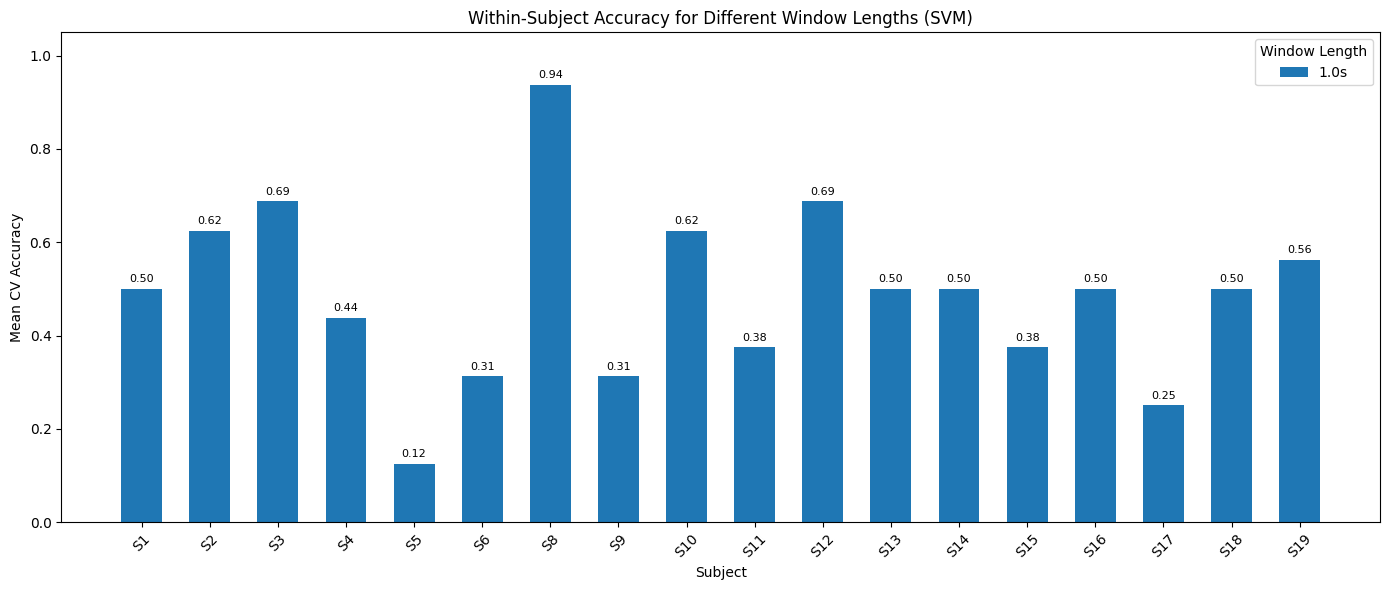

In [16]:
subjects = sorted(subject_epochs.keys(),
                  key=lambda s: int(s[1:]) if s[1:].isdigit() else s)

acc_matrix = np.array([
    [within_results[w][s]["mean_acc_trial"] for w in window_lengths]
    for s in subjects
])

x = np.arange(len(subjects))
n_groups = len(window_lengths)

plt.figure(figsize=(14, 6))

# Adaptive bar width
if n_groups == 1:
    bar_width = 0.6
else:
    bar_width = 0.8 / n_groups  # total group width = 0.8

for j, w in enumerate(window_lengths):

    if n_groups == 1:
        offsets = x
    else:
        offsets = x - (n_groups - 1) / 2 * bar_width + j * bar_width

    vals = acc_matrix[:, j]

    plt.bar(offsets, vals,
            width=bar_width,
            label=f"{w}s")

    # value labels
    for i, acc in enumerate(vals):
        plt.text(offsets[i], acc + 0.01, f"{acc:.2f}",
                 ha="center", va="bottom", fontsize=8)

plt.xlabel("Subject")
plt.ylabel("Mean CV Accuracy")
plt.title(f"Within-Subject Accuracy for Different Window Lengths ({clf_type.upper()})")

# IMPORTANT: ticks must be centered at x
plt.xticks(x, subjects, rotation=45)

plt.ylim(0, 1.05)
plt.legend(title="Window Length")
plt.tight_layout()
plt.show()

logreg_75% overlap_ with_trial_index_so_no_leakage

In [17]:
import matplotlib.pyplot as plt

window_lengths = [1.0]
clf_type = "logreg"

within_results = {}

for win_len in window_lengths:

    print("=" * 60)
    print(f"Running window length = {win_len}")
    print("=" * 60)

    within_results[win_len] = {}

    for subj, epochs in subject_epochs.items():

        print(f"Subject: {subj}")

        res = within_subject_riemann_tangent_windowed(
            epochs,                     # <-- pass epochs, not dict
            fmin=8, fmax=30,
            win_len=win_len,
            step=0.25*win_len,
            n_splits=4,
            clf_type=clf_type
        )

        within_results[win_len][subj] = res

Running window length = 1.0
Subject: S1
Subject: S2
Subject: S3
Subject: S4
Subject: S5
Subject: S6
Subject: S8
Subject: S9
Subject: S10
Subject: S11
Subject: S12
Subject: S13
Subject: S14
Subject: S15
Subject: S16
Subject: S17
Subject: S18
Subject: S19


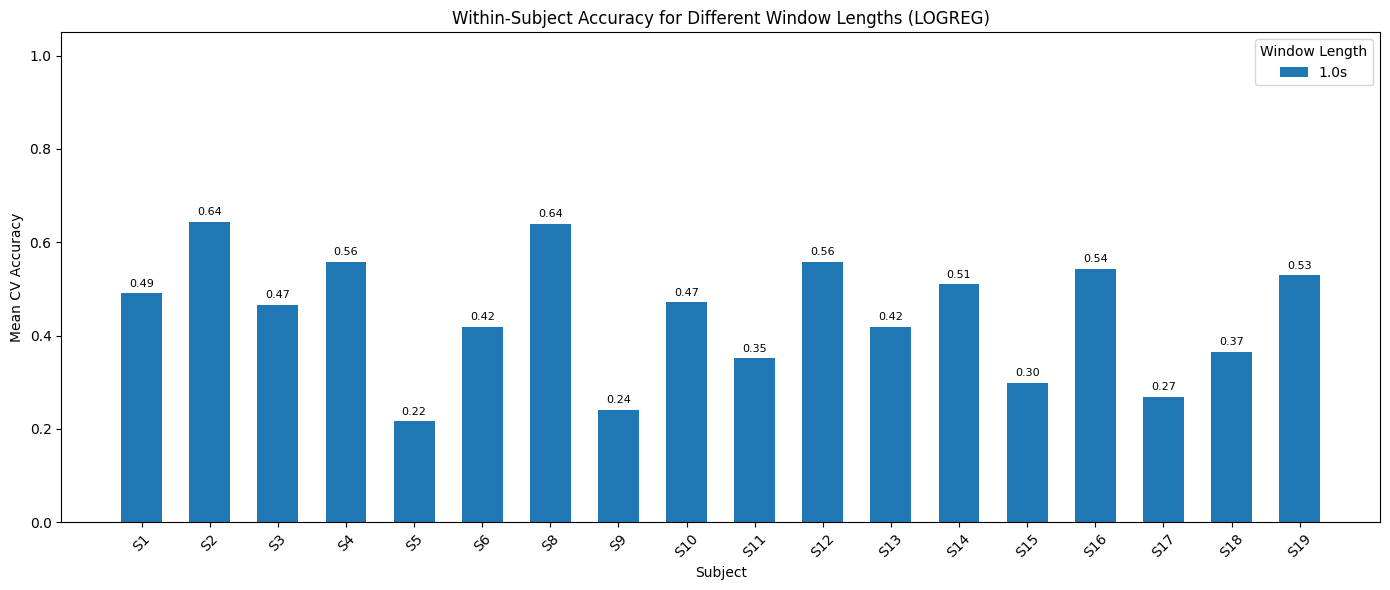

In [18]:
subjects = sorted(subject_epochs.keys(),
                  key=lambda s: int(s[1:]) if s[1:].isdigit() else s)

acc_matrix = np.array([
    [within_results[w][s]["mean_acc_window"] for w in window_lengths]
    for s in subjects
])

x = np.arange(len(subjects))
n_groups = len(window_lengths)

plt.figure(figsize=(14, 6))

# Adaptive bar width
if n_groups == 1:
    bar_width = 0.6
else:
    bar_width = 0.8 / n_groups  # total group width = 0.8

for j, w in enumerate(window_lengths):

    if n_groups == 1:
        offsets = x
    else:
        offsets = x - (n_groups - 1) / 2 * bar_width + j * bar_width

    vals = acc_matrix[:, j]

    plt.bar(offsets, vals,
            width=bar_width,
            label=f"{w}s")

    # value labels
    for i, acc in enumerate(vals):
        plt.text(offsets[i], acc + 0.01, f"{acc:.2f}",
                 ha="center", va="bottom", fontsize=8)

plt.xlabel("Subject")
plt.ylabel("Mean CV Accuracy")
plt.title(f"Within-Subject Accuracy for Different Window Lengths ({clf_type.upper()})")

# IMPORTANT: ticks must be centered at x
plt.xticks(x, subjects, rotation=45)

plt.ylim(0, 1.05)
plt.legend(title="Window Length")
plt.tight_layout()
plt.show()

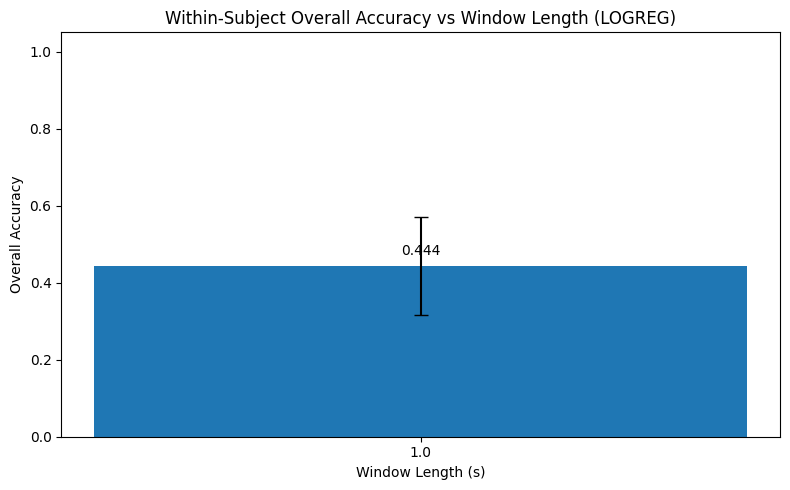

In [19]:
overall_accs = []
overall_stds = []

for w in window_lengths:
    subj_overall_accs = [
        within_results[w][subj]["mean_acc_window"]
        for subj in within_results[w]
    ]
    overall_accs.append(np.mean(subj_overall_accs))
    overall_stds.append(np.std(subj_overall_accs))


# Use numeric x positions (important for consistency)
xw = np.arange(len(window_lengths))
window_labels = [str(w) for w in window_lengths]

plt.figure(figsize=(8, 5))

bars = plt.bar(xw,
               overall_accs,
               yerr=overall_stds,
               capsize=5,
               width=0.6)

# value labels
for i, acc in enumerate(overall_accs):
    plt.text(xw[i], acc + 0.02, f"{acc:.3f}",
             ha="center", va="bottom", fontsize=10)

plt.xticks(xw, window_labels)
plt.xlabel("Window Length (s)")
plt.ylabel("Overall Accuracy")
plt.title(f"Within-Subject Overall Accuracy vs Window Length ({clf_type.upper()})")

plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

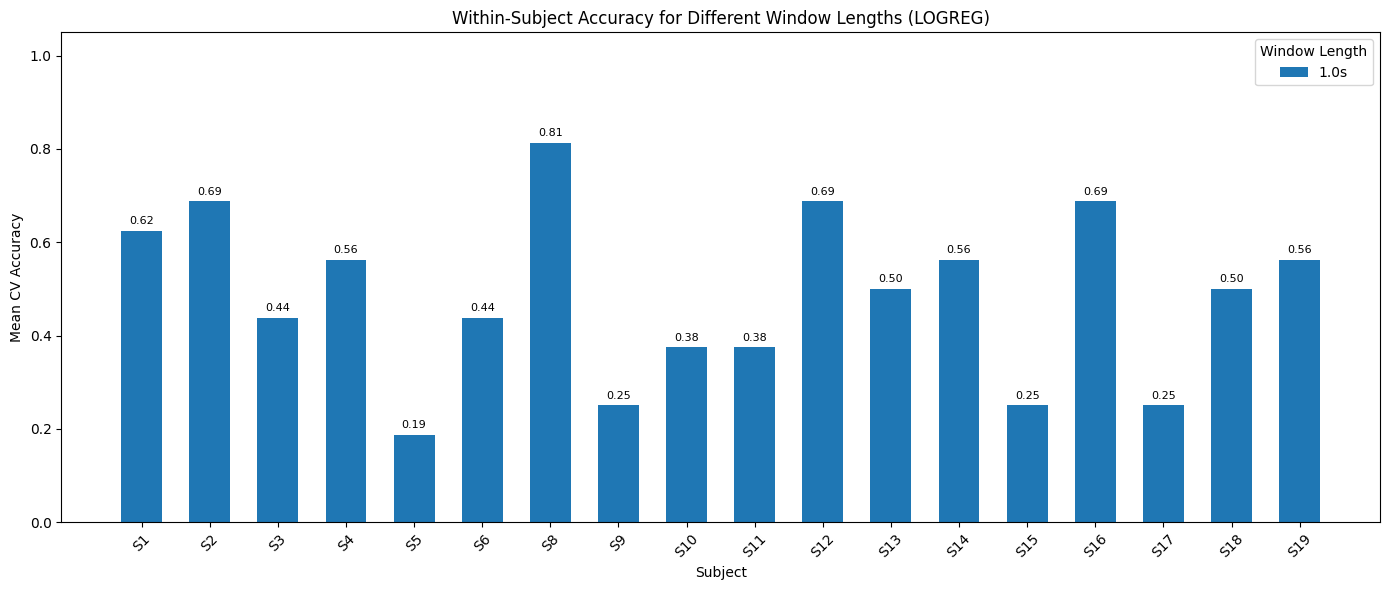

In [20]:
subjects = sorted(subject_epochs.keys(),
                  key=lambda s: int(s[1:]) if s[1:].isdigit() else s)

acc_matrix = np.array([
    [within_results[w][s]["mean_acc_trial"] for w in window_lengths]
    for s in subjects
])

x = np.arange(len(subjects))
n_groups = len(window_lengths)

plt.figure(figsize=(14, 6))

# Adaptive bar width
if n_groups == 1:
    bar_width = 0.6
else:
    bar_width = 0.8 / n_groups  # total group width = 0.8

for j, w in enumerate(window_lengths):

    if n_groups == 1:
        offsets = x
    else:
        offsets = x - (n_groups - 1) / 2 * bar_width + j * bar_width

    vals = acc_matrix[:, j]

    plt.bar(offsets, vals,
            width=bar_width,
            label=f"{w}s")

    # value labels
    for i, acc in enumerate(vals):
        plt.text(offsets[i], acc + 0.01, f"{acc:.2f}",
                 ha="center", va="bottom", fontsize=8)

plt.xlabel("Subject")
plt.ylabel("Mean CV Accuracy")
plt.title(f"Within-Subject Accuracy for Different Window Lengths ({clf_type.upper()})")

# IMPORTANT: ticks must be centered at x
plt.xticks(x, subjects, rotation=45)

plt.ylim(0, 1.05)
plt.legend(title="Window Length")
plt.tight_layout()
plt.show()